## tune-base-weights.ipynb

Tunes the four base block weights (`W_TAGS`, `W_LABELS`, `W_TYPES`, `W_RATINGS`)
for the V3 model, with all other weights fixed at their best values from
`tune-weights.ipynb`.

Only ratios between weights matter after L2 normalisation, so `W_TAGS=1.0`
is fixed as the reference scale throughout.

### Strategy
| Phase | Approach | Combinations |
|---|---|---|
| 1 | Random search over W_LABELS, W_TYPES, W_RATINGS | 50 samples |
| 2 | Focused 5×5 grid around Phase 1 best for the two most sensitive weights | 25 combinations |

In [1]:
import os
import json
import time
import pickle
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import load_npz, hstack

DATA_DIR     = '../data'
FEATURES_DIR = f'{DATA_DIR}/features'
N_RESULTS    = 10
CHUNK_SIZE   = 50_000
K_TOP        = 30
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

# Load best weights from previous tuning
with open(f'{DATA_DIR}/best_weights.json') as f:
    best_weights = json.load(f)

V3_FIXED = best_weights['v3']
print('Fixed V3 weights (non-base):')
for k, v in V3_FIXED.items():
    if k not in ('W_TAGS','W_LABELS','W_TYPES','W_RATINGS'):
        print(f'  {k:<18} = {v}')

Fixed V3 weights (non-base):
  W_COUNTRY          = 1.0
  W_TRACK_STATS      = 0.25
  W_ROLE_FAMILY      = 0.05
  W_INSTRUMENT       = 0.03
  W_CONTRIB_CNT      = 0.0


In [2]:
# Load and scope-filter ground truth
try:
    lastfm = pd.read_parquet(f'{DATA_DIR}/lastfm_similar_albums.parquet')
except Exception:
    lastfm = pd.read_csv(f'{DATA_DIR}/lastfm_similar_albums.csv')

lastfm.columns = lastfm.columns.str.strip()
for col in ['album','artist','similar_album','similar_artist']:
    lastfm[col + '_key'] = lastfm[col].str.lower().str.strip()

mb_lookup = (
    pd.read_parquet(f'{DATA_DIR}/mb_album_artists.parquet',
                    columns=['album_id','album_name','artist_name'])
    .drop_duplicates(subset='album_id')
)
mb_lookup['album_key']  = mb_lookup['album_name'].str.lower().str.strip()
mb_lookup['artist_key'] = mb_lookup['artist_name'].str.lower().str.strip()
mb_index = mb_lookup.set_index(['album_key','artist_key'])['album_id']

seed_pairs = lastfm[['album_key','artist_key']].drop_duplicates()
seed_pairs = seed_pairs.join(mb_index.rename('seed_mb_id'),
                              on=['album_key','artist_key'], how='left')
lastfm = lastfm.join(mb_index.rename('similar_mb_id'),
                      on=['similar_album_key','similar_artist_key'], how='left')
lastfm = lastfm.merge(seed_pairs, on=['album_key','artist_key'], how='left')

ground_truth_raw = (
    lastfm.dropna(subset=['seed_mb_id','similar_mb_id'])
    .groupby('seed_mb_id')['similar_mb_id']
    .apply(set).to_dict()
)
ground_truth_raw = {int(k): {int(v) for v in vs} for k, vs in ground_truth_raw.items()}
print(f'Ground truth (raw): {len(ground_truth_raw):,} seed albums')

Ground truth (raw): 2,421 seed albums


In [3]:
# Load feature blocks
with open(f'{FEATURES_DIR}/album_ids.pkl', 'rb') as f:
    album_id_order = pickle.load(f)

X_tags        = load_npz(f'{FEATURES_DIR}/album_tags_matrix.npz')
X_labels      = load_npz(f'{FEATURES_DIR}/album_labels_matrix.npz')
X_types       = load_npz(f'{FEATURES_DIR}/album_types_matrix.npz')
X_ratings     = load_npz(f'{FEATURES_DIR}/album_ratings_matrix.npz')
X_country     = load_npz(f'{FEATURES_DIR}/album_country_matrix.npz')
X_track_stats = load_npz(f'{FEATURES_DIR}/album_track_stats_matrix.npz')
X_role_family = load_npz(f'{FEATURES_DIR}/album_role_family_matrix.npz')
X_instrument  = load_npz(f'{FEATURES_DIR}/album_instrument_matrix.npz')
X_contrib_cnt = load_npz(f'{FEATURES_DIR}/album_contributor_counts_matrix.npz')

# Expand to full album universe
full_album_ids = pd.Index(
    pd.read_parquet(f'{DATA_DIR}/mb_album.parquet', columns=['id'])['id'].sort_values()
)
from scipy.sparse import csr_matrix

def _expand(X, row_pos, n):
    coo = X.tocoo()
    return csr_matrix((coo.data, (row_pos[coo.row], coo.col)), shape=(n, X.shape[1]))

if len(album_id_order) < len(full_album_ids):
    pos   = full_album_ids.get_indexer(album_id_order)
    n_full = len(full_album_ids)
    X_tags        = _expand(X_tags,        pos, n_full)
    X_labels      = _expand(X_labels,      pos, n_full)
    X_types       = _expand(X_types,       pos, n_full)
    X_ratings     = _expand(X_ratings,     pos, n_full)
    X_country     = _expand(X_country,     pos, n_full)
    X_track_stats = _expand(X_track_stats, pos, n_full)
    X_role_family = _expand(X_role_family, pos, n_full)
    X_instrument  = _expand(X_instrument,  pos, n_full)
    X_contrib_cnt = _expand(X_contrib_cnt, pos, n_full)
    album_id_order = full_album_ids.tolist()

print('Feature blocks loaded and expanded.')

Feature blocks loaded and expanded.


In [4]:
# Clean blocks, compute row norms, resolve seeds
X_base_full = hstack([X_tags, X_labels, X_types, X_ratings]).tocsr()
has_feat    = np.diff(X_base_full.indptr) > 0
ann_ids     = np.array(album_id_order)[has_feat]
id2row_ann  = {int(aid): i for i, aid in enumerate(ann_ids)}
n_ann       = int(has_feat.sum())
all_model_ids = set(int(x) for x in ann_ids)
print(f'Annotated albums: {n_ann:,}')

def _clean(X):
    M = X[has_feat].tocsr().astype(np.float32)
    np.nan_to_num(M.data, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
    M.eliminate_zeros()
    return M

BLK = {
    'tags':        _clean(X_tags),
    'labels':      _clean(X_labels),
    'types':       _clean(X_types),
    'ratings':     _clean(X_ratings),
    'country':     _clean(X_country),
    'track_stats': _clean(X_track_stats),
    'role_family': _clean(X_role_family),
    'instrument':  _clean(X_instrument),
    'contrib_cnt': _clean(X_contrib_cnt),
}
BLK_ROW_SQ = {
    k: np.asarray(M.power(2).sum(axis=1)).ravel().astype(np.float32)
    for k, M in BLK.items()
}

# Scope-filter ground truth
ground_truth = {
    k: {v for v in vs if v in all_model_ids}
    for k, vs in ground_truth_raw.items()
}
ground_truth = {k: vs for k, vs in ground_truth.items() if k in id2row_ann and vs}

seed_ids   = list(ground_truth.keys())
seed_rows  = np.array([id2row_ann[s] for s in seed_ids], dtype=np.int32)
seed_known = [ground_truth[s] for s in seed_ids]
n_seeds    = len(seed_ids)
print(f'Seeds in model index: {n_seeds:,}')

# Seed sparse submatrices and norms
SEED_BLK      = {k: BLK[k][seed_rows] for k in BLK}
SEED_NORMS_SQ = {k: BLK_ROW_SQ[k][seed_rows] for k in BLK}

Annotated albums: 1,008,102
Seeds in model index: 1,974


In [5]:
# ── Pre-compute SEED_DOTS for base blocks only (float16, ~16 GB total) ────
#
# Only the 4 base blocks are being searched — pre-storing their dot products
# removes 4 sparse matmuls from every evaluate_weights call.
# The 5 fixed blocks (country, track_stats, role_family, instrument, contrib_cnt)
# stay sparse and contribute a constant offset to every evaluation, so they
# only need computing once outside the search loop.
#
# Memory budget:
#   BASE SEED_DOTS : 4 blocks × n_seeds × n_ann × 2 bytes
#                  = 4 × 1,997 × 1,008,102 × 2  ≈  16 GB
#   Sparse BLK     : ~2 GB  (kept for fixed blocks)
#   chunk_buf      : ~400 MB (transient)
#   Total peak     : ~18–19 GB  ✓ fits in 32 GB

import time

BASE_BLOCKS  = ['tags', 'labels', 'types', 'ratings']
FIXED_BLOCKS = ['country', 'track_stats', 'role_family', 'instrument', 'contrib_cnt']

print('Pre-computing base block dot products as float16...')
t0 = time.time()
SEED_DOTS     = {}
SEED_NORMS_SQ = {}
for k in BASE_BLOCKS:
    M = BLK[k]
    Q = M[seed_rows]                                       # sparse (n_seeds × ncols)
    D = np.ascontiguousarray(
            M.dot(Q.T).toarray().T.astype(np.float16))    # (n_seeds × n_ann) float16
    SEED_DOTS[k]     = D
    SEED_NORMS_SQ[k] = BLK_ROW_SQ[k][seed_rows].astype(np.float32)
    print(f'  {k:<14} {str(D.shape):<22} {D.nbytes/1e9:.2f} GB  ({time.time()-t0:.0f}s)')

# Pre-compute fixed-block dot products once — (n_seeds × n_ann) float32
# These are constant across all search iterations so computed only here.
print('Pre-computing fixed block dot products (constant across search)...')
FIXED_DOTS     = np.zeros((n_seeds, n_ann), dtype=np.float32)
FIXED_NORMS_SQ = np.zeros(n_seeds, dtype=np.float32)   # query norm contribution
FIXED_CAND_SQ  = np.zeros(n_ann,   dtype=np.float32)   # candidate norm contribution

for k in FIXED_BLOCKS:
    w  = np.float32(V3_FIXED.get(
        'W_' + k.upper().replace('_STATS','_STATS')
        .replace('TRACK_STATS','TRACK_STATS'), 0.0))
    # Map block name to weight key
    wkey = {
        'country':     'W_COUNTRY',
        'track_stats': 'W_TRACK_STATS',
        'role_family': 'W_ROLE_FAMILY',
        'instrument':  'W_INSTRUMENT',
        'contrib_cnt': 'W_CONTRIB_CNT',
    }[k]
    w = np.float32(V3_FIXED.get(wkey, 0.0))
    if w == 0.0:
        continue
    w2 = np.float32(w ** 2)
    M  = BLK[k]
    Q  = M[seed_rows]
    D  = M.dot(Q.T).toarray().T.astype(np.float32)        # (n_seeds × n_ann)
    FIXED_DOTS     += w2 * D
    FIXED_NORMS_SQ += w2 * BLK_ROW_SQ[k][seed_rows]
    FIXED_CAND_SQ  += w2 * BLK_ROW_SQ[k]
    print(f'  {k:<14} w={w:.3f}  added to FIXED_DOTS')

print(f'\nPre-computation done in {time.time()-t0:.0f}s')
print(f'FIXED_DOTS non-zero: {(FIXED_DOTS != 0).sum():,}')

Pre-computing base block dot products as float16...
  tags           (1974, 1008102)        3.98 GB  (35s)
  labels         (1974, 1008102)        3.98 GB  (69s)
  types          (1974, 1008102)        3.98 GB  (108s)
  ratings        (1974, 1008102)        3.98 GB  (142s)
Pre-computing fixed block dot products (constant across search)...
  country        w=1.000  added to FIXED_DOTS
  track_stats    w=0.250  added to FIXED_DOTS
  role_family    w=0.050  added to FIXED_DOTS
  instrument     w=0.030  added to FIXED_DOTS

Pre-computation done in 390s
FIXED_DOTS non-zero: 1,986,646,134


In [6]:
# ── evaluate_weights: base blocks from SEED_DOTS, fixed blocks pre-summed ─
# Per call: 4 numpy accumulations (base) + constant offset (fixed) + chunked top-N
# Peak transient: n_seeds × CHUNK_SIZE × 4 bytes ≈ 400 MB

def evaluate_weights(weights: dict, n: int = N_RESULTS) -> dict:
    # Base block weights (searched)
    w2_tags    = np.float32(weights.get('W_TAGS',    1.0) ** 2)
    w2_labels  = np.float32(weights.get('W_LABELS',  1.0) ** 2)
    w2_types   = np.float32(weights.get('W_TYPES',   1.0) ** 2)
    w2_ratings = np.float32(weights.get('W_RATINGS', 1.0) ** 2)

    base_w2 = {
        'tags':    w2_tags,
        'labels':  w2_labels,
        'types':   w2_types,
        'ratings': w2_ratings,
    }

    # Candidate norms: base contribution + fixed contribution
    cand_norm_sq = FIXED_CAND_SQ.copy()             # fixed blocks (pre-computed)
    for k, w2 in base_w2.items():
        cand_norm_sq += w2 * BLK_ROW_SQ[k]
    cand_norms = np.sqrt(cand_norm_sq)
    cand_norms[cand_norms == 0] = 1.0

    # Query norms: base + fixed
    q_norm_sq = FIXED_NORMS_SQ.copy()               # (n_seeds,)
    for k, w2 in base_w2.items():
        q_norm_sq += w2 * SEED_NORMS_SQ[k]
    q_norms = np.sqrt(q_norm_sq)
    q_norms[q_norms == 0] = 1.0

    # Running top-K across column chunks
    best_scores = np.full((n_seeds, K_TOP), -np.inf, dtype=np.float32)
    best_cols   = np.zeros((n_seeds, K_TOP), dtype=np.int32)
    chunk_buf   = np.empty((n_seeds, CHUNK_SIZE), dtype=np.float32)

    for col_start in range(0, n_ann, CHUNK_SIZE):
        col_end = min(col_start + CHUNK_SIZE, n_ann)
        csize   = col_end - col_start
        chunk   = chunk_buf[:, :csize]

        # Fixed block contribution for this chunk (slice of pre-computed matrix)
        chunk[:] = FIXED_DOTS[:, col_start:col_end]

        # Base block contributions — fast float16→float32 accumulation
        for k, w2 in base_w2.items():
            chunk += w2 * SEED_DOTS[k][:, col_start:col_end].astype(np.float32)

        # Cosine
        chunk /= q_norms[:, None]
        chunk /= cand_norms[None, col_start:col_end]

        # Mask self
        self_mask = (seed_rows >= col_start) & (seed_rows < col_end)
        for s_idx in np.where(self_mask)[0]:
            chunk[s_idx, seed_rows[s_idx] - col_start] = -1.0

        # Merge into running top-K
        k_use = min(K_TOP, csize)
        chunk_top_idx    = np.argpartition(chunk, -k_use, axis=1)[:, -k_use:]
        chunk_top_scores = chunk[np.arange(n_seeds)[:, None], chunk_top_idx]
        chunk_top_cols   = (chunk_top_idx + col_start).astype(np.int32)
        combined_scores  = np.concatenate([best_scores, chunk_top_scores], axis=1)
        combined_cols    = np.concatenate([best_cols,   chunk_top_cols],   axis=1)
        keep             = np.argpartition(combined_scores, -K_TOP, axis=1)[:, -K_TOP:]
        best_scores      = combined_scores[np.arange(n_seeds)[:, None], keep]
        best_cols        = combined_cols[  np.arange(n_seeds)[:, None], keep]

    order      = np.argsort(best_scores, axis=1)[:, ::-1]
    sorted_idx = best_cols[np.arange(n_seeds)[:, None], order]

    hits, precs, rrs = [], [], []
    for s_idx in range(n_seeds):
        known = seed_known[s_idx]
        s_id  = seed_ids[s_idx]
        recs  = [int(ann_ids[i]) for i in sorted_idx[s_idx]
                 if int(ann_ids[i]) != s_id][:n]
        overlap = set(recs) & known
        hits.append(1 if overlap else 0)
        precs.append(len(overlap) / n)
        rr = 0.0
        for rank, aid in enumerate(recs, 1):
            if aid in known: rr = 1.0 / rank; break
        rrs.append(rr)

    return {
        'hit_rate':  float(np.mean(hits)),
        'precision': float(np.mean(precs)),
        'mrr':       float(np.mean(rrs)),
        'n_eval':    len(hits),
    }


# V3 reference
print('V3 reference (base weights all 1.0)...')
t0 = time.time()
v3_ref  = evaluate_weights(V3_FIXED)
elapsed = time.time() - t0
print(f'V3 ref  hit={v3_ref["hit_rate"]:.4f}  prec={v3_ref["precision"]:.4f}  '
      f'mrr={v3_ref["mrr"]:.4f}  ({elapsed:.1f}s)')
print(f'Estimated Phase 1 (50 samples): {50 * elapsed / 60:.1f} min')
print(f'Estimated Phase 2 (25 combos) : {25 * elapsed / 60:.1f} min')

V3 reference (base weights all 1.0)...
V3 ref  hit=0.0699  prec=0.0078  mrr=0.0285  (78.6s)
Estimated Phase 1 (50 samples): 65.5 min
Estimated Phase 2 (25 combos) : 32.7 min


In [7]:
# ── Phase 1: random search over W_LABELS, W_TYPES, W_RATINGS ─────────────
# W_TAGS fixed at 1.0 — reference scale
N_SAMPLES = 50

def log_uniform(lo, hi):
    return float(np.exp(np.random.uniform(np.log(lo), np.log(hi))))

SEARCH_SPACE = {
    'W_LABELS':  (0.3, 3.0),
    'W_TYPES':   (0.1, 5.0),
    'W_RATINGS': (0.1, 5.0),
}

p1_results = []
print(f'Phase 1 random search: {N_SAMPLES} samples  (W_TAGS=1.0 fixed)')
t0 = time.time()

for i in range(1, N_SAMPLES + 1):
    sample = {**V3_FIXED,
              'W_TAGS':    1.0,
              'W_LABELS':  log_uniform(*SEARCH_SPACE['W_LABELS']),
              'W_TYPES':   log_uniform(*SEARCH_SPACE['W_TYPES']),
              'W_RATINGS': log_uniform(*SEARCH_SPACE['W_RATINGS']),
             }
    scores = evaluate_weights(sample)
    p1_results.append({**sample, **scores})
    if i % 10 == 0:
        best    = max(p1_results, key=lambda r: r['hit_rate'])
        elapsed = time.time() - t0
        eta     = elapsed / i * (N_SAMPLES - i)
        print(f'  [{i}/{N_SAMPLES}]  best hit={best["hit_rate"]:.4f}  '
              f'labels={best["W_LABELS"]:.3f}  types={best["W_TYPES"]:.3f}  '
              f'ratings={best["W_RATINGS"]:.3f}  elapsed={elapsed:.0f}s  eta={eta:.0f}s')

p1_df   = pd.DataFrame(p1_results).sort_values('hit_rate', ascending=False)
p1_best = p1_df.iloc[0]
print(f'\nTotal: {time.time()-t0:.0f}s')
print(f'\n=== Phase 1 best ===')
print(p1_df[['W_LABELS','W_TYPES','W_RATINGS','hit_rate','precision','mrr']]
      .head(10).round(4).to_string(index=False))

Phase 1 random search: 50 samples  (W_TAGS=1.0 fixed)
  [10/50]  best hit=0.0724  labels=0.343  types=2.962  ratings=1.050  elapsed=492s  eta=1969s
  [20/50]  best hit=0.0745  labels=0.325  types=3.507  ratings=0.275  elapsed=941s  eta=1412s
  [30/50]  best hit=0.0745  labels=0.325  types=3.507  ratings=0.275  elapsed=1390s  eta=927s
  [40/50]  best hit=0.0745  labels=0.325  types=3.507  ratings=0.275  elapsed=1839s  eta=460s
  [50/50]  best hit=0.0745  labels=0.325  types=3.507  ratings=0.275  elapsed=2286s  eta=0s

Total: 2287s

=== Phase 1 best ===
 W_LABELS  W_TYPES  W_RATINGS  hit_rate  precision    mrr
   0.3247   3.5068     0.2752    0.0745     0.0084 0.0295
   0.3429   2.9622     1.0502    0.0724     0.0081 0.0287
   1.2601   0.3649     0.1282    0.0724     0.0082 0.0290
   0.5357   0.6995     0.3245    0.0724     0.0081 0.0294
   0.4150   2.3063     0.1339    0.0724     0.0082 0.0289
   1.2153   0.1949     0.1290    0.0719     0.0081 0.0289
   0.4136   0.3136     0.4192    0.0

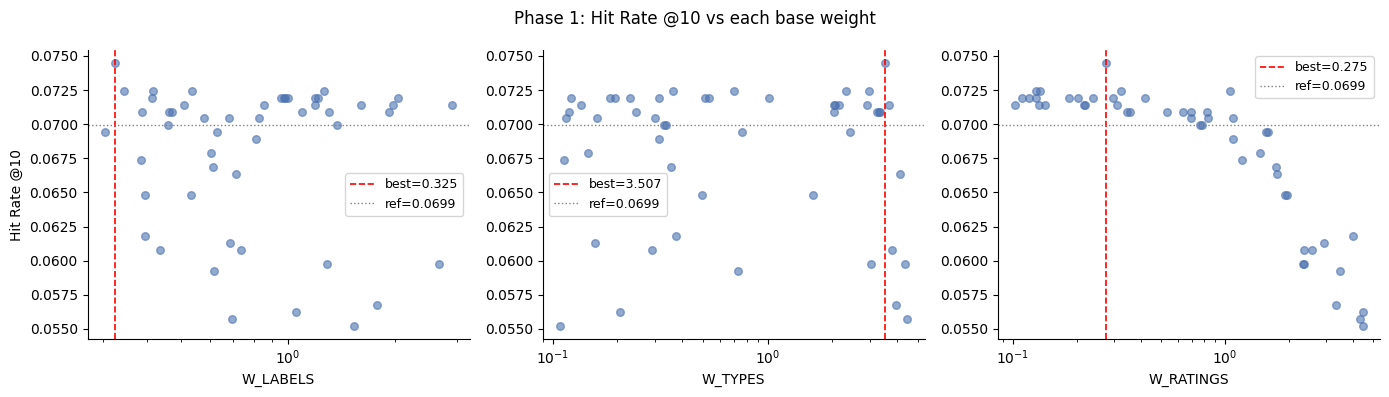

Saved: tune_base_scatter.png

Identify the two weights with the clearest trend above, then run Phase 2.


In [8]:
# Scatter plots — which weights show sensitivity?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Phase 1: Hit Rate @10 vs each base weight', fontsize=12)

for ax, col in zip(axes, ['W_LABELS','W_TYPES','W_RATINGS']):
    ax.scatter(p1_df[col], p1_df['hit_rate'], alpha=0.6, s=30, color='#4C72B0')
    ax.axvline(float(p1_best[col]), color='red', linestyle='--', linewidth=1.2,
               label=f'best={p1_best[col]:.3f}')
    ax.axhline(v3_ref['hit_rate'], color='grey', linestyle=':', linewidth=1,
               label=f'ref={v3_ref["hit_rate"]:.4f}')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Hit Rate @10' if ax == axes[0] else '')
    ax.set_xscale('log')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tune_base_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tune_base_scatter.png')
print()
print('Identify the two weights with the clearest trend above, then run Phase 2.')

In [9]:
# ── Phase 2: focused 5×5 grid around Phase 1 best ─────────────────────────
# Set the two most sensitive weights below based on the scatter plots.
# The third weight is fixed at its Phase 1 best value.
# Default: W_LABELS and W_RATINGS — adjust if scatter shows otherwise.

WEIGHT_A = 'W_LABELS'    # most sensitive — change if scatter shows otherwise
WEIGHT_B = 'W_RATINGS'   # second most sensitive
WEIGHT_C = 'W_TYPES'     # fixed at Phase 1 best

best_a = float(p1_best[WEIGHT_A])
best_b = float(p1_best[WEIGHT_B])
best_c = float(p1_best[WEIGHT_C])

# 5 values centred on best, ±40% in log space
def log_grid(centre, n=5, spread=0.4):
    log_c = np.log(centre)
    return np.exp(np.linspace(log_c - spread, log_c + spread, n)).tolist()

GRID_A = log_grid(best_a)
GRID_B = log_grid(best_b)

p2_results = []
total = len(GRID_A) * len(GRID_B)
print(f'Phase 2 grid: {WEIGHT_A} × {WEIGHT_B}  ({total} combinations)')
print(f'  {WEIGHT_A} values: {[round(v,3) for v in GRID_A]}')
print(f'  {WEIGHT_B} values: {[round(v,3) for v in GRID_B]}')
print(f'  {WEIGHT_C} fixed at {best_c:.3f}')
t0 = time.time()

for i, (wa, wb) in enumerate(itertools.product(GRID_A, GRID_B), 1):
    sample = {**V3_FIXED,
              'W_TAGS':    1.0,
              WEIGHT_A:    wa,
              WEIGHT_B:    wb,
              WEIGHT_C:    best_c,
             }
    scores = evaluate_weights(sample)
    p2_results.append({WEIGHT_A: wa, WEIGHT_B: wb, **scores})
    if i % 5 == 0:
        best = max(p2_results, key=lambda r: r['hit_rate'])
        print(f'  [{i}/{total}]  best hit={best["hit_rate"]:.4f}  '
              f'{WEIGHT_A}={best[WEIGHT_A]:.3f}  {WEIGHT_B}={best[WEIGHT_B]:.3f}  '
              f'elapsed={time.time()-t0:.0f}s')

p2_df   = pd.DataFrame(p2_results).sort_values('hit_rate', ascending=False)
p2_best = p2_df.iloc[0]
print(f'\nTotal: {time.time()-t0:.0f}s')
print(f'\n=== Phase 2 best ===')
print(p2_df.head(10).round(4).to_string(index=False))

Phase 2 grid: W_LABELS × W_RATINGS  (25 combinations)
  W_LABELS values: [0.218, 0.266, 0.325, 0.397, 0.484]
  W_RATINGS values: [0.184, 0.225, 0.275, 0.336, 0.411]
  W_TYPES fixed at 3.507
  [5/25]  best hit=0.0735  W_LABELS=0.218  W_RATINGS=0.184  elapsed=225s
  [10/25]  best hit=0.0745  W_LABELS=0.266  W_RATINGS=0.184  elapsed=446s
  [15/25]  best hit=0.0750  W_LABELS=0.325  W_RATINGS=0.184  elapsed=664s
  [20/25]  best hit=0.0750  W_LABELS=0.325  W_RATINGS=0.184  elapsed=889s
  [25/25]  best hit=0.0750  W_LABELS=0.325  W_RATINGS=0.184  elapsed=1110s

Total: 1110s

=== Phase 2 best ===
 W_LABELS  W_RATINGS  hit_rate  precision    mrr  n_eval
   0.3247     0.1845    0.0750     0.0085 0.0293    1974
   0.3247     0.2253    0.0750     0.0085 0.0293    1974
   0.3247     0.2752    0.0745     0.0084 0.0295    1974
   0.2659     0.1845    0.0745     0.0085 0.0292    1974
   0.2659     0.2253    0.0745     0.0085 0.0292    1974
   0.3247     0.3361    0.0745     0.0084 0.0296    1974
   0.

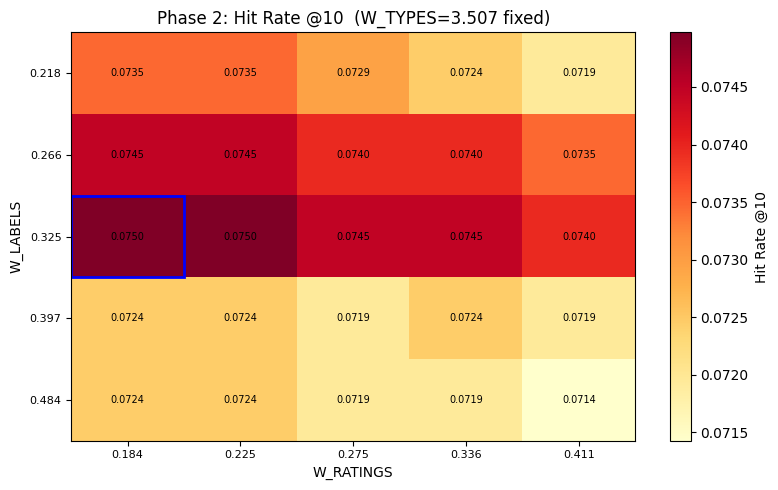

In [10]:
# Heatmap
pivot = p2_df.pivot(index=WEIGHT_A, columns=WEIGHT_B, values='hit_rate')

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Hit Rate @10')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'{v:.3f}' for v in pivot.columns], fontsize=8)
ax.set_yticklabels([f'{v:.3f}' for v in pivot.index], fontsize=8)
ax.set_xlabel(WEIGHT_B); ax.set_ylabel(WEIGHT_A)
ax.set_title(f'Phase 2: Hit Rate @10  ({WEIGHT_C}={best_c:.3f} fixed)')
for (r, c), val in np.ndenumerate(pivot.values):
    ax.text(c, r, f'{val:.4f}', ha='center', va='center', fontsize=7)
br = list(pivot.index).index(float(p2_best[WEIGHT_A]))
bc = list(pivot.columns).index(float(p2_best[WEIGHT_B]))
ax.add_patch(plt.Rectangle((bc-0.5, br-0.5), 1, 1,
             fill=False, edgecolor='blue', lw=2))
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tune_base_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Final comparison
final_weights = {
    **V3_FIXED,
    'W_TAGS':    1.0,
    WEIGHT_A:    float(p2_best[WEIGHT_A]),
    WEIGHT_B:    float(p2_best[WEIGHT_B]),
    WEIGHT_C:    best_c,
}
final_scores = evaluate_weights(final_weights)

print('=== Final comparison ===')
print(f'{"Model":<22} {"Hit Rate":>10} {"Precision":>10} {"MRR":>8}')
print('-' * 54)
print(f'{"V3 reference (all 1.0)":<22} {v3_ref["hit_rate"]:>10.4f} '
      f'{v3_ref["precision"]:>10.4f} {v3_ref["mrr"]:>8.4f}')
print(f'{"V3 base-tuned":<22} {final_scores["hit_rate"]:>10.4f} '
      f'{final_scores["precision"]:>10.4f} {final_scores["mrr"]:>8.4f}')
print()
print('Best base weights:')
for k in ['W_TAGS','W_LABELS','W_TYPES','W_RATINGS']:
    print(f'  {k:<12} = {final_weights[k]:.4f}')

=== Final comparison ===
Model                    Hit Rate  Precision      MRR
------------------------------------------------------
V3 reference (all 1.0)     0.0699     0.0078   0.0285
V3 base-tuned              0.0750     0.0085   0.0293

Best base weights:
  W_TAGS       = 1.0000
  W_LABELS     = 0.3247
  W_TYPES      = 3.5068
  W_RATINGS    = 0.1845


In [13]:
for w_r in [0.02, 0.05, 0.08, 0.12, 0.15, 0.18]:
    s = evaluate_weights({**V3_FIXED, 'W_TAGS':1.0, 'W_LABELS':0.325, 'W_TYPES':3.507, 'W_RATINGS':w_r})
    print(f'W_RATINGS={w_r:.2f}  hit={s["hit_rate"]:.4f}')

W_RATINGS=0.02  hit=0.0750
W_RATINGS=0.05  hit=0.0750
W_RATINGS=0.08  hit=0.0750
W_RATINGS=0.12  hit=0.0750
W_RATINGS=0.15  hit=0.0750
W_RATINGS=0.18  hit=0.0750


In [12]:
# Update best_weights.json with tuned base weights
best_weights['v3'].update({
    'W_TAGS':    1.0,
    WEIGHT_A:    float(p2_best[WEIGHT_A]),
    WEIGHT_B:    float(p2_best[WEIGHT_B]),
    WEIGHT_C:    best_c,
})

out_path = f'{DATA_DIR}/best_weights.json'
with open(out_path, 'w') as f:
    json.dump(best_weights, f, indent=2)

print(f'Updated {out_path}')
print(json.dumps(best_weights['v3'], indent=2))
print()
print('Run load-best-weights cell in tune-weights.ipynb to rebuild the model.')

Updated ../data/best_weights.json
{
  "W_TAGS": 1.0,
  "W_LABELS": 0.32472055144502865,
  "W_TYPES": 3.5067764992972172,
  "W_RATINGS": 0.18447674779954779,
  "W_COUNTRY": 1.0,
  "W_TRACK_STATS": 0.25,
  "W_ROLE_FAMILY": 0.05,
  "W_INSTRUMENT": 0.03,
  "W_CONTRIB_CNT": 0.0
}

Run load-best-weights cell in tune-weights.ipynb to rebuild the model.


In [14]:
import json

with open('../data/best_weights.json') as f:
    bw = json.load(f)

bw['v3']['W_RATINGS'] = 0.1   # flat landscape confirmed 0.02–0.275, use round number

with open('../data/best_weights.json', 'w') as f:
    json.dump(bw, f, indent=2)

print(json.dumps(bw['v3'], indent=2))

{
  "W_TAGS": 1.0,
  "W_LABELS": 0.32472055144502865,
  "W_TYPES": 3.5067764992972172,
  "W_RATINGS": 0.1,
  "W_COUNTRY": 1.0,
  "W_TRACK_STATS": 0.25,
  "W_ROLE_FAMILY": 0.05,
  "W_INSTRUMENT": 0.03,
  "W_CONTRIB_CNT": 0.0
}
